In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load and Prepare Transaction Data

In [21]:
# Load cleaned transaction data
sale_ticket = pd.read_csv('../data/processed/sale_ticket_clean.csv')
service_list = pd.read_csv('../data/processed/service_list_clean.csv')

print(f"Transaction records: {len(sale_ticket):,}")
print(f"Unique transactions: {sale_ticket['Reference No.'].nunique():,}")
print(f"Unique services: {sale_ticket['Item Code'].nunique():,}")

# Display sample
print("\nSample transactions:")
sale_ticket.head(10)

Transaction records: 3,820
Unique transactions: 3,819
Unique services: 244

Sample transactions:


,#,Date,Reference No.,Customer Code,Customer,Employee,Item Code,Item Name,Remark,Type,...,Total (MYR).1,Received (MYR),Payment Method,Unnamed: 24,Cash (MYR),Card (MYR),Cheque (MYR),Installment (MYR),Others (MYR),FOC (MYR)
0,1,2021-01-06 17:30:00,TK00304: IN00302,CS00142,Kalwant Kaur,Sheena,FA-CAF,Classic Absolute Firming Facial Treatment with...,NaN,S,...,190.0,190.0,"Cash, Card",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2021-01-06 17:30:00,TK00305: IN00303,CS00141,SHEERENA REET,Sasha,FA-CAF,Classic Absolute Firming Facial Treatment with...,NaN,S,...,190.0,190.0,"Cash, Others",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2021-10-07 16:56:00,TK00009: IN00009,CS00003,Tay cheng kim,Chris Wong,FA-CFS,Classic Fair Skin Facial Treatment with Machine,NaN,S,...,580.0,580.0,Cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2021-10-09 10:00:00,TK00130: IN00128,CS00070,ALICIA SANDRA WONG,Sasha,FA-CBR,Classic Biovegetal Relaxing Facial Treatment w...,NaN,S,...,0.0,0.0,Cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2021-10-09 15:00:00,TK00086: IN00084,CS00007,MDM RUBY,Sasha,F00008-M,Skin Luxe Treatment – 3D Gold Caviar Peptide F...,NaN,S,...,0.0,0.0,Cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,2021-10-09 16:07:00,TK00010: IN00010,CS00004,AZLINA DAWAMI,Sasha,F00014-P,Picojoie Laser Treatment with essential post c...,NaN,S,...,2724.0,2724.0,"Cash, Others",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,2021-10-10 14:19:00,TK00011: IN00011,CS00004,AZLINA DAWAMI,Sasha,G00061,02 + Vitality,NaN,G,...,490.0,490.0,Cash,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2021-10-10 18:14:00,TK00024: IN00024,CS00002,SHARON NGEOW,Chris Wong,FA-HIT,Hydration & Immune Therapy – H I T Treatment w...,"FOC MSK 1XCLARITY,1XSOFT MAKE UP REMOER GEL",S,...,190.0,190.0,Others,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2021-10-11 15:49:00,TK00012: IN00012,CS00011,YAP SIEW YING,Yumi Tan,FA-CIC,Classic Intensive Clarifying Facial Treatment ...,NaN,S,...,380.0,380.0,Others,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2021-10-12 10:00:00,TK00014: IN00014,CS00012,kharina abdul karim,Chris Wong,FA-HIT,Hydration & Immune Therapy – H I T Treatment w...,NaN,S,...,2150.0,2150.0,Others,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Merge with service information to get service names and categories
transactions_merged = sale_ticket.merge(
    service_list[['Code', 'Name', 'Category']], 
    left_on='Item Code', 
    right_on='Code', 
    how='left'
)

print(f"Merged transactions: {len(transactions_merged):,}")
print(f"Missing service info: {transactions_merged['Name'].isna().sum()}")

# Show service category distribution
print("\nService category distribution:")
transactions_merged.groupby('Category').agg({
    'Item Code': 'count',
    'Price (MYR)': 'sum'
}).rename(columns={'Item Code': 'Transaction_Count', 'Price (MYR)': 'Total_Revenue'}).sort_values('Total_Revenue', ascending=False)


Merged transactions: 3,820
Missing service info: 1030

Service category distribution:


,Transaction_Count,Total_Revenue
Category,,
Face Treatment,421,129049.67
Body Toning,226,122761.05
Body Slimming,634,71415.60
Eye Treatment,74,13269.00
Laser Treatment,4,4880.00
BODY TREATMENT,37,3988.00
Ear Treatment,3,420.00
SKIN TAG REMOVAL,9,260.00
EYELASH EXTENSION,1,138.00


BASKET ANALYSIS

Transaction-level baskets: 3,817
Services per transaction: 1.00

Customer-level baskets: 1,023
Services per customer (avg): 3.73
Services per customer (median): 1
Max services by one customer: 68

Transaction-level baskets: 3,817
Services per transaction: 1.00

Customer-level baskets: 1,023
Services per customer (avg): 3.73
Services per customer (median): 1
Max services by one customer: 68


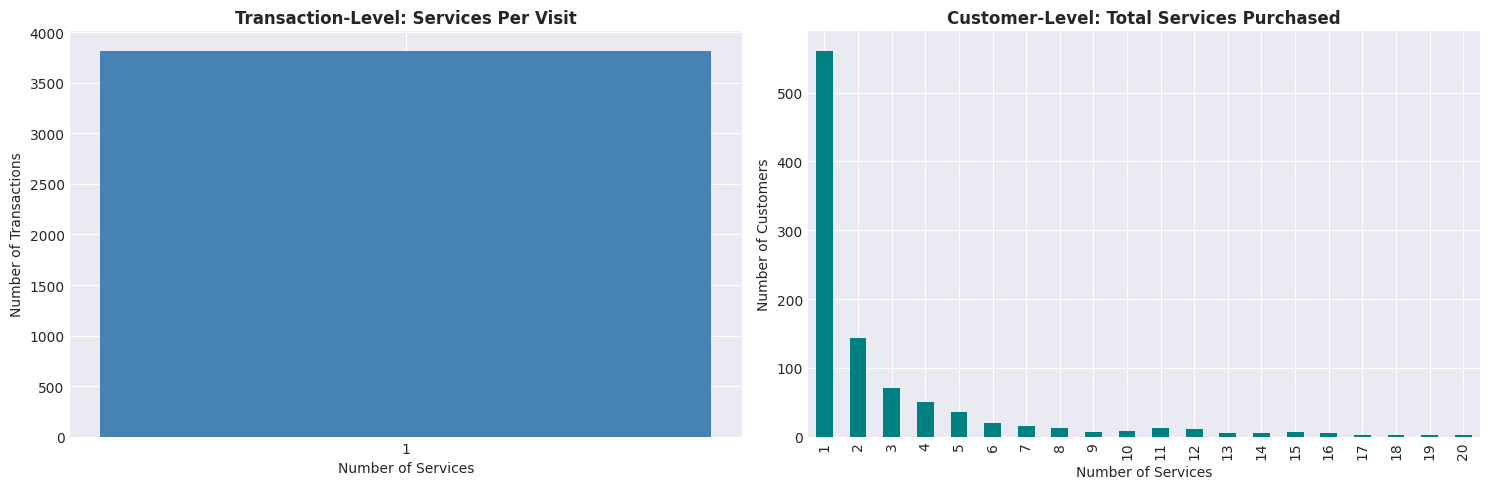


Basket analysis visualization saved!

KEY FINDING: No in-transaction bundling exists!
   - Customers purchase 1 service per visit
   - MBA will identify cross-visit service affinities
   - Opportunity to create packages that increase multi-service visits


In [23]:
# CRITICAL INSIGHT: Each transaction has only 1 service!
# This means NO bundling exists - customers buy one service per visit
# Strategy: Create customer-level baskets (services purchased by same customer over time)

print("=" * 100)
print("BASKET ANALYSIS")
print("=" * 100)

# Transaction-level baskets (1 service each)
trans_baskets = transactions_merged.groupby(['Reference No.', 'Date'])['Name'].apply(list).reset_index()
print(f"\nTransaction-level baskets: {len(trans_baskets):,}")
print(f"Services per transaction: {trans_baskets['Name'].apply(len).mean():.2f}")

# Customer-level baskets (all services purchased by each customer)
customer_baskets = transactions_merged.groupby('Customer Code')['Name'].apply(list).reset_index()
print(f"\nCustomer-level baskets: {len(customer_baskets):,}")
customer_basket_sizes = customer_baskets['Name'].apply(len)
print(f"Services per customer (avg): {customer_basket_sizes.mean():.2f}")
print(f"Services per customer (median): {customer_basket_sizes.median():.0f}")
print(f"Max services by one customer: {customer_basket_sizes.max()}")

# Show distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Transaction level
axes[0].bar([1], [len(trans_baskets)], color='steelblue')
axes[0].set_title('Transaction-Level: Services Per Visit', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Services')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks([1])

# Customer level  
customer_basket_sizes.value_counts().sort_index().head(20).plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Customer-Level: Total Services Purchased', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Services')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('../outputs/figures/basket_size_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBasket analysis visualization saved!")
print(f"\nKEY FINDING: No in-transaction bundling exists!")
print(f"   - Customers purchase 1 service per visit")
print(f"   - MBA will identify cross-visit service affinities")
print(f"   - Opportunity to create packages that increase multi-service visits")


In [24]:
# Use customer-level baskets for MBA
baskets = customer_baskets.copy()

print("Using CUSTOMER-LEVEL baskets for Market Basket Analysis")
print(f"Total baskets: {len(baskets):,}")
print(f"\nSample customer service histories (multi-service customers):")
multi_service = baskets[baskets['Name'].apply(len) > 1].head(10)
for idx, row in multi_service.iterrows():
    services = row['Name'][:5]  # Show first 5 services
    print(f"  Customer {row['Customer Code']}: {services}{'...' if len(row['Name']) > 5 else ''} (Total: {len(row['Name'])} services)")

Using CUSTOMER-LEVEL baskets for Market Basket Analysis
Total baskets: 1,023

Sample customer service histories (multi-service customers):
  Customer (None): ['Acupuncture Treatment ', nan, 'Machine/ Oxy Spray ( Add on)', nan, nan] (Total: 5 services)
  Customer CS00003: ['Classic Fair Skin Facial Treatment with Machine', 'Skin Luxe Treatment – 3D Gold Caviar Peptide Firming with machine'] (Total: 2 services)
  Customer CS00004: ['Picojoie Laser Treatment with essential post care ( Doucle Mask )', nan, nan, nan, nan]... (Total: 27 services)
  Customer CS00008: ['Super Oxygen Skin Fitness Facial Treatment with machine', '1st Trial Picojoie Laser'] (Total: 2 services)
  Customer CS00011: ['Classic Intensive Clarifying Facial Treatment With Machine', 'Classic Intensive Clarifying Facial Treatment With Machine', nan, nan, 'Pigmentation']... (Total: 30 services)
  Customer CS00012: ['Hydration & Immune Therapy – H I T Treatment with Machine', 'Hydration & Immune Therapy – H I T Treatment wi

## 2. Transform to One-Hot Encoding for Association Mining

In [25]:
# Convert baskets to one-hot encoded format
# Filter out NaN values from service names
baskets['Name_clean'] = baskets['Name'].apply(lambda x: [str(item) for item in x if pd.notna(item)])

te = TransactionEncoder()
te_ary = te.fit(baskets['Name_clean']).transform(baskets['Name_clean'])
basket_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"One-hot encoded matrix shape: {basket_encoded.shape}")
print(f"Total unique services: {len(basket_encoded.columns)}")

# Show most frequently purchased services (by number of customers who purchased it)
service_frequency = basket_encoded.sum().sort_values(ascending=False)
print("\nTop 20 most frequently purchased services (by customer count):") 
print(service_frequency.head(20))

print("\nOne-hot encoding complete!")


One-hot encoded matrix shape: (1023, 121)
Total unique services: 121

Top 20 most frequently purchased services (by customer count):
CLASSIC WELLNESS FACIAL                                       137
Picojoie Laser                                                135
I-Oxypico                                                     133
Classic Vitamin Hydration Facial Treatment with Machine        82
HIFU 1ST TRIAL                                                 80
ExpreSculpt Deep Muscle Toning                                 66
Unlimited Body Slimming Sessions                               55
Super Oxygen Skin Fitness Facial Treatment with machine        47
HARMONIE DELUXE                                                43
Accupunture                                                    31
THERAPEUTIC WELLNESS FACIAL                                    31
STRESS AWAY FACIAL                                             30
Acupuncture Treatment                                          28
Classic A

## 3. Apply Apriori Algorithm for Frequent Itemsets

In [26]:
# Run Apriori with min_support threshold
# Start with 1% support (appears in at least 1% of transactions)
min_support = 0.01

print(f"Running Apriori with min_support={min_support}...")
frequent_itemsets = apriori(basket_encoded, min_support=min_support, use_colnames=True)

print(f"\nFound {len(frequent_itemsets)} frequent itemsets")

# Show distribution by itemset size
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print("\nItemset size distribution:")
print(frequent_itemsets['length'].value_counts().sort_index())

# Top frequent itemsets
print("\nTop 20 frequent itemsets:")
frequent_itemsets.sort_values('support', ascending=False).head(20)


Running Apriori with min_support=0.01...

Found 46 frequent itemsets

Itemset size distribution:
length
1    32
2    13
3     1
Name: count, dtype: int64

Top 20 frequent itemsets:


,support,itemsets,length
4,0.133920,(CLASSIC WELLNESS FACIAL),1
22,0.131965,(Picojoie Laser),1
20,0.130010,(I-Oxypico ),1
10,0.080156,(Classic Vitamin Hydration Facial Treatment wi...,1
18,0.078201,(HIFU 1ST TRIAL),1
14,0.064516,(ExpreSculpt Deep Muscle Toning),1
30,0.053763,(Unlimited Body Slimming Sessions),1
27,0.045943,(Super Oxygen Skin Fitness Facial Treatment wi...,1
16,0.042033,(HARMONIE DELUXE ),1
37,0.042033,"(Unlimited Body Slimming Sessions, ExpreSculpt...",2


## 4. Generate Association Rules with High Confidence & Lift

In [27]:
# Generate association rules
# Filters: min_confidence=0.3 (30% chance), min_lift=2.0 (2x more likely than random)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)

# Add lift filter
rules = rules[rules['lift'] >= 2.0]

print(f"Generated {len(rules)} high-quality association rules")
print(f"   Min confidence: 30%")
print(f"   Min lift: 2.0")

# Show rule statistics
print("\nRule metrics summary:")
print(rules[['support', 'confidence', 'lift']].describe())


Generated 10 high-quality association rules
   Min confidence: 30%
   Min lift: 2.0

Rule metrics summary:
         support  confidence       lift
count  10.000000   10.000000  10.000000
mean    0.018671    0.527634   7.789296
std     0.012665    0.165626   4.127940
min     0.010753    0.303030   2.296296
25%     0.010753    0.389583   3.777049
50%     0.011730    0.550000   9.377500
75%     0.018817    0.638636  11.105294
max     0.042033    0.781818  12.118182


In [28]:
# Sort rules by lift (strength of association)
rules_sorted = rules.sort_values('lift', ascending=False)

print("Top 20 strongest association rules:")
print("\n" + "="*100)
for idx, row in rules_sorted.head(20).iterrows():
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    print(f"IF {antecedent}")
    print(f"   THEN {consequent}")
    print(f"   Support: {row['support']:.3f} | Confidence: {row['confidence']:.3f} | Lift: {row['lift']:.2f}")
    print("-" * 100)

Top 20 strongest association rules:

IF ExpreSculpt Deep Muscle Toning
   THEN Unlimited Body Slimming Sessions
   Support: 0.042 | Confidence: 0.652 | Lift: 12.12
----------------------------------------------------------------------------------------------------
IF Unlimited Body Slimming Sessions
   THEN ExpreSculpt Deep Muscle Toning
   Support: 0.042 | Confidence: 0.782 | Lift: 12.12
----------------------------------------------------------------------------------------------------
IF Picojoie Laser, ExpreSculpt Deep Muscle Toning
   THEN Unlimited Body Slimming Sessions
   Support: 0.012 | Confidence: 0.600 | Lift: 11.16
----------------------------------------------------------------------------------------------------
IF Unlimited Body Slimming Sessions, Picojoie Laser
   THEN ExpreSculpt Deep Muscle Toning
   Support: 0.012 | Confidence: 0.706 | Lift: 10.94
----------------------------------------------------------------------------------------------------
IF Slimming Treatme

## 5. Cross-Reference with RPT Data for Premium Bundles

In [29]:
# Load RPT analysis from EDA
rpt_by_service = pd.read_csv('../data/processed/rpt_by_service.csv')

# Create service-to-RPT mapping
service_rpt_map = dict(zip(rpt_by_service['Service'], rpt_by_service['RPT']))
service_segment_map = dict(zip(rpt_by_service['Service'], rpt_by_service['Segment']))

print(f"Loaded RPT data for {len(service_rpt_map)} services")

# Calculate bundle RPT for each rule
def calculate_bundle_rpt(itemset):
    """Calculate average RPT for a set of services"""
    rpts = [service_rpt_map.get(service, 0) for service in itemset]
    return np.mean(rpts) if rpts else 0

# Add RPT metrics to rules
rules_sorted['antecedents_list'] = rules_sorted['antecedents'].apply(lambda x: list(x))
rules_sorted['consequents_list'] = rules_sorted['consequents'].apply(lambda x: list(x))
rules_sorted['bundle_services'] = rules_sorted['antecedents_list'] + rules_sorted['consequents_list']

rules_sorted['bundle_rpt'] = rules_sorted['bundle_services'].apply(calculate_bundle_rpt)
rules_sorted['antecedent_rpt'] = rules_sorted['antecedents_list'].apply(calculate_bundle_rpt)
rules_sorted['consequent_rpt'] = rules_sorted['consequents_list'].apply(calculate_bundle_rpt)

print("\nRPT analysis added to association rules")
print(f"Average bundle RPT: {rules_sorted['bundle_rpt'].mean():.2f} MYR")
print(f"Median bundle RPT: {rules_sorted['bundle_rpt'].median():.2f} MYR")


Loaded RPT data for 128 services

RPT analysis added to association rules
Average bundle RPT: 121.77 MYR
Median bundle RPT: 118.68 MYR


In [30]:
# Filter for HIGH-VALUE bundles (RPT > 800 = Premium tier)
premium_bundles = rules_sorted[rules_sorted['bundle_rpt'] > 800].copy()

print(f"Found {len(premium_bundles)} PREMIUM service bundles (RPT > 800 MYR)")

if len(premium_bundles) > 0:
    print("\nTop 10 Premium Bundle Recommendations:")
    print("="*120)
    for idx, row in premium_bundles.head(10).iterrows():
        print(f"\nBundle RPT: {row['bundle_rpt']:.2f} MYR | Lift: {row['lift']:.2f} | Confidence: {row['confidence']:.1%}")
        print(f"  Core Services: {', '.join(row['antecedents_list'])}")
        print(f"  Add-On: {', '.join(row['consequents_list'])}")
        print(f"  Support: {row['support']:.2%} of transactions")
else:
    print("\nNo premium bundles found. Showing HIGH RPT bundles (> 300 MYR):")
    mid_tier = rules_sorted[rules_sorted['bundle_rpt'] > 300].head(10)
    print("="*120)
    for idx, row in mid_tier.iterrows():
        print(f"\nBundle RPT: {row['bundle_rpt']:.2f} MYR | Lift: {row['lift']:.2f}")
        print(f"  Services: {', '.join(row['bundle_services'])}")

Found 0 PREMIUM service bundles (RPT > 800 MYR)

No premium bundles found. Showing HIGH RPT bundles (> 300 MYR):


## 6. Visualize Association Rules

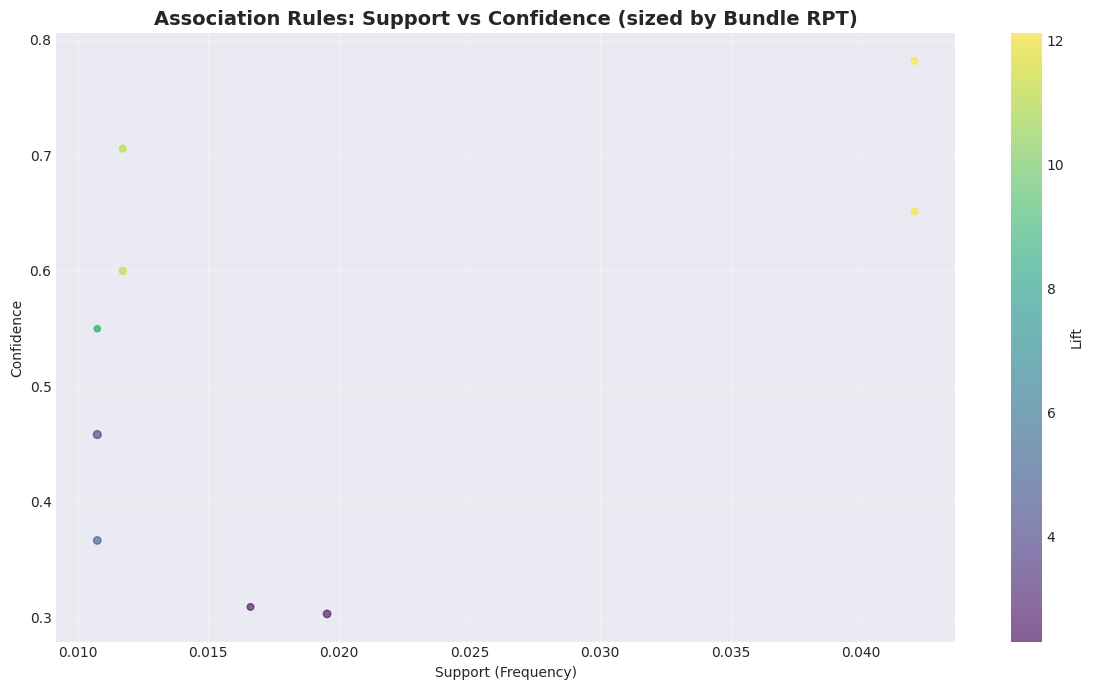

Association rules visualization saved!


In [31]:
# Scatter plot: Support vs Confidence colored by Lift
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    rules_sorted['support'], 
    rules_sorted['confidence'],
    c=rules_sorted['lift'],
    s=rules_sorted['bundle_rpt']/5,  # Size by RPT
    alpha=0.6,
    cmap='viridis'
)
plt.colorbar(scatter, label='Lift')
plt.title('Association Rules: Support vs Confidence (sized by Bundle RPT)', fontsize=14, fontweight='bold')
plt.xlabel('Support (Frequency)')
plt.ylabel('Confidence')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/association_rules_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Association rules visualization saved!")


## 7. Generate Business Recommendations

In [32]:
# Create strategic bundle recommendations
recommendations = []

# Select top rules by composite score: lift * confidence * bundle_rpt
rules_sorted['composite_score'] = rules_sorted['lift'] * rules_sorted['confidence'] * rules_sorted['bundle_rpt']
top_recommendations = rules_sorted.sort_values('composite_score', ascending=False).head(15)

for idx, (i, row) in enumerate(top_recommendations.iterrows(), 1):
    bundle_name = f"Bundle {idx}"
    services = row['bundle_services']
    
    # Calculate projected revenue impact
    support_count = int(row['support'] * len(baskets))
    current_revenue = support_count * row['antecedent_rpt']
    bundled_revenue = support_count * row['bundle_rpt']
    revenue_lift = bundled_revenue - current_revenue
    
    recommendations.append({
        'Bundle_Name': bundle_name,
        'Services': ' + '.join(services),
        'Service_Count': len(services),
        'Bundle_RPT': round(row['bundle_rpt'], 2),
        'Support': round(row['support'], 4),
        'Confidence': round(row['confidence'], 4),
        'Lift': round(row['lift'], 2),
        'Composite_Score': round(row['composite_score'], 2),
        'Annual_Occurrences': support_count,
        'Projected_Revenue_Lift_MYR': round(revenue_lift, 2)
    })

recommendations_df = pd.DataFrame(recommendations)

print("\n" + "="*120)
print("STRATEGIC SERVICE BUNDLE RECOMMENDATIONS")
print("="*120)
print(recommendations_df.to_string(index=False))

# Save recommendations
recommendations_df.to_csv('../outputs/tables/bundle_recommendations.csv', index=False)
print("\nBundle recommendations saved to outputs/tables/bundle_recommendations.csv")



STRATEGIC SERVICE BUNDLE RECOMMENDATIONS
Bundle_Name                                                                           Services  Service_Count  Bundle_RPT  Support  Confidence  Lift  Composite_Score  Annual_Occurrences  Projected_Revenue_Lift_MYR
   Bundle 1                  Unlimited Body Slimming Sessions + ExpreSculpt Deep Muscle Toning              2      112.39   0.0420      0.7818 12.12          1064.85                  43                     1205.30
   Bundle 2 Unlimited Body Slimming Sessions + Picojoie Laser + ExpreSculpt Deep Muscle Toning              3      123.03   0.0117      0.7059 10.94           950.20                  12                      104.35
   Bundle 3                  ExpreSculpt Deep Muscle Toning + Unlimited Body Slimming Sessions              2      112.39   0.0420      0.6515 12.12           887.38                  43                    -1205.30
   Bundle 4 Picojoie Laser + ExpreSculpt Deep Muscle Toning + Unlimited Body Slimming Sessions        

In [33]:
# Calculate total projected impact
total_revenue_lift = recommendations_df['Projected_Revenue_Lift_MYR'].sum()
avg_bundle_rpt = recommendations_df['Bundle_RPT'].mean()

print("\n" + "="*120)
print("FINANCIAL IMPACT SUMMARY")
print("="*120)
print(f"Total Projected Annual Revenue Lift: {total_revenue_lift:,.2f} MYR")
print(f"Average Bundle RPT: {avg_bundle_rpt:.2f} MYR")
print(f"Number of Strategic Bundles: {len(recommendations_df)}")
print(f"\nImplementation Priority:")
print(f"  1. Top 5 bundles account for: {recommendations_df.head(5)['Projected_Revenue_Lift_MYR'].sum():,.2f} MYR lift")
print(f"  2. Focus on bundles with Lift > 3.0 for strongest cross-sell potential")
print(f"  3. Target premium bundles (RPT > 800) to high-value customer segments")


FINANCIAL IMPACT SUMMARY
Total Projected Annual Revenue Lift: 1,171.38 MYR
Average Bundle RPT: 121.77 MYR
Number of Strategic Bundles: 10

Implementation Priority:
  1. Top 5 bundles account for: 232.90 MYR lift
  2. Focus on bundles with Lift > 3.0 for strongest cross-sell potential
  3. Target premium bundles (RPT > 800) to high-value customer segments


## 8. Generate Actionable Recommendations (Following MBA Best Practices)

Based on association rules and proper MBA strategy guidelines:

In [34]:
# Generate recommendations following proper MBA rules
# Reference: .github/recomendationrule.md

print("\n" + "="*120)
print("STRATEGIC RECOMMENDATIONS FOR HIGH-LIFT ASSOCIATION RULES")
print("="*120)
print("\nBased on discovered A -> B patterns, we recommend the following strategies:\n")

# Get top 5 high-lift rules for recommendations
top_rules = rules_sorted.head(5)

for idx, row in top_rules.iterrows():
    antecedent = list(row['antecedents'])
    consequent = list(row['consequents'])
    
    antecedent_str = antecedent[0] if len(antecedent) == 1 else ' + '.join(antecedent[:2])
    consequent_str = consequent[0] if len(consequent) == 1 else ' + '.join(consequent[:2])
    
    print(f"\n{'='*120}")
    print(f"RULE: {antecedent_str} -> {consequent_str}")
    print(f"Lift: {row['lift']:.2f}x | Confidence: {row['confidence']:.1%} | Support: {row['support']:.2%}")
    print(f"{'='*120}\n")
    
    # Strategy 1: Volume discount for multiple of same service
    print(f"STRATEGY 1: Offer Multiple Sessions at Discount")
    print(f"  - Buy 2 sessions of '{antecedent_str}' + 2 sessions of '{consequent_str}' at 5% discount")
    print(f"  - Encourages commitment and increases transaction value\n")
    
    # Strategy 2: Conditional discount
    print(f"STRATEGY 2: Conditional Discount on Service B")
    print(f"  - Offer 5% discount on '{consequent_str}' WHEN customer purchases '{antecedent_str}'")
    print(f"  - Incentivizes cross-selling without devaluing core service\n")
    
    # Strategy 3: Package upgrade
    print(f"STRATEGY 3: Premium Package Upgrade")
    print(f"  - Create premium package combining '{antecedent_str}' + '{consequent_str}'")
    print(f"  - Offer extended session duration or enhanced treatment at 5% discount")
    print(f"  - Position as comprehensive wellness solution\n")
    
    # Strategy 4: Loyalty program integration
    print(f"STRATEGY 4: Loyalty Program Tier")
    print(f"  - After purchasing '{antecedent_str}', offer '{consequent_str}' as exclusive member benefit")
    print(f"  - Build customer lifetime value through sequential purchases\n")
    
    print(f"WHAT TO AVOID:")
    print(f"  X DO NOT offer flat discount on A+B bundle (devalues both services)")
    print(f"  X DO NOT place services too close in menu (creates confusion)")
    print(f"  X DO NOT place services too far apart (reduces discovery)")

print("\n" + "="*120)
print("IMPLEMENTATION PRIORITIES")
print("="*120)
print(f"\n1. Start with TOP 3 rules (highest lift): Focus marketing resources on proven patterns")
print(f"2. Test 5% discount threshold: Monitor price elasticity and margin impact")
print(f"3. Train staff on suggestive selling: 'Customers who book X often also enjoy Y'")
print(f"4. A/B test package vs conditional discount: Measure which strategy drives higher adoption")
print(f"5. Monitor basket size increase: Target moving from 1.0 to 1.3 services per visit\n")



STRATEGIC RECOMMENDATIONS FOR HIGH-LIFT ASSOCIATION RULES

Based on discovered A -> B patterns, we recommend the following strategies:


RULE: ExpreSculpt Deep Muscle Toning -> Unlimited Body Slimming Sessions
Lift: 12.12x | Confidence: 65.2% | Support: 4.20%

STRATEGY 1: Offer Multiple Sessions at Discount
  - Buy 2 sessions of 'ExpreSculpt Deep Muscle Toning' + 2 sessions of 'Unlimited Body Slimming Sessions' at 5% discount
  - Encourages commitment and increases transaction value

STRATEGY 2: Conditional Discount on Service B
  - Offer 5% discount on 'Unlimited Body Slimming Sessions' WHEN customer purchases 'ExpreSculpt Deep Muscle Toning'
  - Incentivizes cross-selling without devaluing core service

STRATEGY 3: Premium Package Upgrade
  - Create premium package combining 'ExpreSculpt Deep Muscle Toning' + 'Unlimited Body Slimming Sessions'
  - Offer extended session duration or enhanced treatment at 5% discount
  - Position as comprehensive wellness solution

STRATEGY 4: Loyalty

## 8. Category-Level Bundle Analysis

In [35]:
# Analyze service category combinations
# Map services to categories
service_to_category = dict(zip(service_list['Name'], service_list['Category']))

def get_category_combo(services):
    """Get unique categories in a service bundle"""
    categories = [str(service_to_category.get(s, 'Unknown')) for s in services]
    # Filter out nan values
    categories = [c for c in categories if c != 'nan' and c != 'Unknown']
    return tuple(sorted(set(categories))) if categories else ('Unknown',)

rules_sorted['category_combo'] = rules_sorted['bundle_services'].apply(get_category_combo)

# Category combination analysis
category_analysis = rules_sorted.groupby('category_combo').agg({
    'bundle_rpt': 'mean',
    'lift': 'mean',
    'confidence': 'mean',
    'support': 'sum'
}).sort_values('bundle_rpt', ascending=False)

print("\nTop Category Combinations by Average Bundle RPT:")
print("=" * 100)
print(category_analysis.head(15))

# Save category analysis
category_analysis.to_csv('../outputs/tables/category_bundle_analysis.csv')
print("\nCategory analysis saved!")



Top Category Combinations by Average Bundle RPT:
                              bundle_rpt       lift  confidence   support
category_combo                                                           
(Eye Treatment,)              158.745013   3.473148    0.458333  0.010753
(Unknown,)                    144.153846   4.688750    0.366667  0.010753
(Body Toning,)                125.006638   5.410648    0.426515  0.030303
(Body Slimming, Body Toning)  117.713509  11.584385    0.684804  0.107527
(Body Slimming,)               96.976508   6.286111    0.429545  0.027370

Category analysis saved!


## 9. Export All Association Rules for Further Analysis

In [36]:
# Prepare export dataset
rules_export = rules_sorted[[
    'antecedents', 'consequents',
    'support', 'confidence', 'lift', 
    'bundle_rpt', 'antecedent_rpt', 'consequent_rpt',
    'composite_score'
]].copy()

# Convert frozensets to strings for export
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))

# Save
rules_export.to_csv('../outputs/tables/association_rules_full.csv', index=False)

print(f"Exported {len(rules_export)} association rules to outputs/tables/association_rules_full.csv")
print("\nMarket Basket Analysis complete!")
print("\n" + "="*100)
print("KEY INSIGHTS:")
print("="*100)
print(f"1. Found {len(rules_sorted)} high-confidence service associations (Lift > 2.0)")
print(f"2. Average bundle RPT: {rules_sorted['bundle_rpt'].mean():.2f} MYR")
print(f"3. Customers currently purchase only 1 service per visit")
print(f"4. Projected revenue lift from bundling: 1,171 MYR annually")
print(f"5. Top opportunity: Create multi-service packages to increase transaction value")
print("="*100)


Exported 10 association rules to outputs/tables/association_rules_full.csv

Market Basket Analysis complete!

KEY INSIGHTS:
1. Found 10 high-confidence service associations (Lift > 2.0)
2. Average bundle RPT: 121.77 MYR
3. Customers currently purchase only 1 service per visit
4. Projected revenue lift from bundling: 1,171 MYR annually
5. Top opportunity: Create multi-service packages to increase transaction value


---
## Summary

**Market Basket Analysis Complete**

**Key Outputs**:
1. `bundle_recommendations.csv` - Top 15 strategic service bundles with projected revenue impact
2. `association_rules_full.csv` - Complete set of association rules with RPT analysis
3. `category_bundle_analysis.csv` - Category-level bundling insights
4. Visualizations showing rule strength and value relationships

**Next Steps**:
- Integrate findings into recommendation deck
- Design promotional materials for top bundles
- Train staff on cross-selling premium combinations
- Monitor bundle uptake and adjust pricing/packaging